In [9]:
# Install requirements
! pip install numpy pandas scikit-learn matplotlib seaborn kagglehub



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
import xgboost as xgb
import kagglehub
import warnings
import time
from datetime import datetime
import json
warnings.filterwarnings('ignore')
np.random.seed(42)

In [16]:
# Download the NSL-KDD dataset
print("Downloading NSL-KDD dataset")
path = kagglehub.dataset_download("hassan06/nslkdd")
print("Path to dataset files:", path)

In [ ]:
def load_nslkdd_dataset(dataset_path):
    # Load and prepare the NSL-KDD dataset
    print("Loading NSL-KDD dataset")

    # Define the expected 42 column names for the dataset
    column_names = [
        'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
        'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
        'logged_in', 'num_compromised', 'root_shell', 'su_attempted',
        'num_root', 'num_file_creations', 'num_shells', 'num_access_files',
        'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count',
        'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate',
        'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate',
        'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate',
        'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
        'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
        'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
        'dst_host_srv_rerror_rate', 'class', 'difficulty'
    ]

    try:
        # Read training and test data files
        train_df = pd.read_csv(dataset_path + '/KDDTrain+.txt', names=column_names, header=None)
        test_df = pd.read_csv(dataset_path + '/KDDTest+.txt', names=column_names, header=None)

        # Combine training and test data into one table
        df = pd.concat([train_df, test_df], ignore_index=True)

        # Print column names to verify structure
        print("Dataset columns:", list(df.columns))

        # Remove 'difficulty' column since we don't need it
        df = df.drop('difficulty', axis=1)

        # Create a new column 'label': 0 for normal, 1 for attack
        df['label'] = (df['class'] != 'normal').astype(int)

        # Show how many of each attack type are in the data
        print("Attack type distribution:")
        print(df['class'].value_counts().head(10))

        # Convert text columns to numbers
        categorical_features = ['protocol_type', 'service', 'flag']
        label_encoders = {}  # Store encoders for later use
        for feature in categorical_features:
            if feature in df.columns:
                le = LabelEncoder()  # Tool to turn text into numbers
                df[feature] = le.fit_transform(df[feature].astype(str))
                label_encoders[feature] = le
            else:
                print(f"Warning: {feature} not found in dataset")

        # Get list of feature names (exclude 'class' and 'label')
        feature_names = [col for col in df.columns if col not in ['class', 'label']]

        # Fix missing or infinite values
        df = df.replace([np.inf, -np.inf], np.nan)  # Replace infinite values with NaN
        df = df.fillna(0)  # Replace NaN with 0

        # Show basic info about the dataset
        print("Dataset shape:", df.shape)
        print("Normal samples:", sum(df['label'] == 0))
        print("Malicious samples:", sum(df['label'] == 1))
        print("Features:", len(feature_names))
        print("Feature names:", feature_names)

        return df, feature_names, label_encoders  # Return data, features, and encoders

    except Exception as e:
        # If something goes wrong, show error and return None
        print("Error loading dataset:", e)
        return None, None, None

In [ ]:
def prepare_data(df, feature_names):
    # Prepare data for training the models
    print("Preparing data")

    # Verify that all feature_names exist in the DataFrame
    missing_features = [f for f in feature_names if f not in df.columns]
    if missing_features:
        print("Error: Missing features in DataFrame:", missing_features)
        return None, None, None, None, None

    # Split data into features (X) and labels (y)
    X = df[feature_names]  # Features (inputs)
    y = df['label']  # Labels (normal or attack)

    # Split data into 70% training and 30% testing
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    # Scale features to have similar ranges
    scaler = StandardScaler()  # Tool to scale data
    X_train_scaled = scaler.fit_transform(X_train)  # Scale training data
    X_test_scaled = scaler.transform(X_test)  # Scale test data

    # Show sizes of training and test sets
    print("Training set shape:", X_train_scaled.shape)
    print("Test set shape:", X_test_scaled.shape)
    print("Training set - Normal:", sum(y_train == 0), "Malicious:", sum(y_train == 1))
    print("Test set - Normal:", sum(y_test == 0), "Malicious:", sum(y_test == 1))

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler  # Return prepared data

In [ ]:
def calculate_metrics(y_true, y_pred):
    # Calculate how well the model performs
    return {
        'accuracy': accuracy_score(y_true, y_pred),  # How often the model is correct
        'precision': precision_score(y_true, y_pred, zero_division=0),  # How accurate attack predictions are
        'recall': recall_score(y_true, y_pred, zero_division=0),  # How many attacks the model catches
        'f1': f1_score(y_true, y_pred, zero_division=0),  # Balance of precision and recall
        'confusion_matrix': confusion_matrix(y_true, y_pred),  # Table of prediction results
        'y_pred': y_pred  # Store predictions
    }

In [ ]:
def train_intrusion_models(X_train, y_train, X_test, y_test):
    # Train intrusion detection models (Random Forest and XGBoost)
    print("Training Intrusion Detection Models")
    intrusion_models = {}  # Store trained models
    before_attack_results = {}  # Store results before attacks

    # Train Random Forest model
    print("\nTraining Random Forest")
    start_time = time.time()
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)  # Create model
    rf_model.fit(X_train, y_train)  # Train model
    rf_training_time = time.time() - start_time
    rf_pred = rf_model.predict(X_test)  # Make predictions
    rf_metrics = calculate_metrics(y_test, rf_pred)  # Get performance
    rf_metrics['training_time'] = rf_training_time  # Add training time
    intrusion_models['Random Forest'] = rf_model  # Save model
    before_attack_results['Random Forest'] = rf_metrics  # Save results

    # Print Random Forest results immediately
    print("Random Forest Results (Before Attacks):")
    print(f"  Accuracy: {rf_metrics['accuracy']:.4f}")
    print(f"  Precision: {rf_metrics['precision']:.4f}")
    print(f"  Recall: {rf_metrics['recall']:.4f}")
    print(f"  F1-Score: {rf_metrics['f1']:.4f}")
    print(f"  Training Time: {rf_training_time:.2f} seconds")
    print()

    # Train XGBoost model
    print("Training XGBoost")
    start_time = time.time()
    xgb_model = xgb.XGBClassifier(n_estimators=100, random_state=42, max_depth=6)
    xgb_model.fit(X_train, y_train)  # Train model
    xgb_training_time = time.time() - start_time
    xgb_pred = xgb_model.predict(X_test)  # Make predictions
    xgb_metrics = calculate_metrics(y_test, xgb_pred)  # Get performance
    xgb_metrics['training_time'] = xgb_training_time  # Add training time
    intrusion_models['XGBoost'] = xgb_model  # Save model
    before_attack_results['XGBoost'] = xgb_metrics  # Save results

    # Print XGBoost results immediately
    print("XGBoost Results (Before Attacks):")
    print(f"  Accuracy: {xgb_metrics['accuracy']:.4f}")
    print(f"  Precision: {xgb_metrics['precision']:.4f}")
    print(f"  Recall: {xgb_metrics['recall']:.4f}")
    print(f"  F1-Score: {xgb_metrics['f1']:.4f}")
    print(f"  Training Time: {xgb_training_time:.2f} seconds")
    print()

    return intrusion_models, before_attack_results

In [ ]:
def feature_manipulation_attack(model, X_test, y_test, perturbation_strength=0.1):
    # Try to trick the model by slightly changing attack data
    print("Feature Manipulation Attack")

    # Find attack samples using boolean indexing
    malicious_mask = (y_test == 1)
    if not malicious_mask.any():
        print("No malicious samples found in test set")
        return None

    malicious_samples = X_test[malicious_mask].copy()  # Copy attack samples
    print("Malicious samples shape:", malicious_samples.shape)

    # Add small random changes
    noise = np.random.normal(0, perturbation_strength, malicious_samples.shape)
    adversarial_samples = malicious_samples + noise  # Create modified samples

    # Predict on original and modified samples
    original_pred = model.predict(malicious_samples)
    adversarial_pred = model.predict(adversarial_samples)

    # Check how often modified attacks are missed
    evasion_success = np.mean(adversarial_pred == 0) if len(adversarial_pred) > 0 else 0

    # Calculate metrics for modified samples
    y_test_subset = y_test[malicious_mask]
    after_attack_metrics = calculate_metrics(y_test_subset, adversarial_pred)

    # Print attack results immediately
    print("Feature Manipulation Attack Results:")
    print(f"  Evasion Success Rate: {evasion_success:.4f}")
    print(f"  Accuracy: {after_attack_metrics['accuracy']:.4f}")
    print(f"  Precision: {after_attack_metrics['precision']:.4f}")
    print(f"  Recall: {after_attack_metrics['recall']:.4f}")
    print(f"  F1-Score: {after_attack_metrics['f1']:.4f}")
    print()

    return {
        'attack_type': 'feature_manipulation',
        'evasion_success': evasion_success,
        'adversarial_samples': adversarial_samples,
        'adversarial_pred': adversarial_pred,
        'original_pred': original_pred,
        'malicious_mask': malicious_mask,
        'perturbation_strength': perturbation_strength,
        'after_attack_metrics': after_attack_metrics
    }


In [ ]:

def gradient_based_attack(model, X_test, y_test, epsilon=0.1):
    # Try to trick the model using important features
    print("Gradient-Based Attack")

    # Find attack samples using boolean indexing
    malicious_mask = (y_test == 1)
    if not malicious_mask.any():
        print("No malicious samples found in test set")
        return None

    malicious_samples = X_test[malicious_mask].copy()
    print("Malicious samples shape:", malicious_samples.shape)

    # Use feature importance (if available)
    if hasattr(model, 'feature_importances_'):
        feature_importance = model.feature_importances_
    else:
        feature_importance = np.ones(malicious_samples.shape[1]) / malicious_samples.shape[1]

    # Verify feature importance shape matches sample shape
    if len(feature_importance) != malicious_samples.shape[1]:
        print("Error: Feature importance shape does not match sample shape")
        return None

    # Modify samples based on important features
    adversarial_samples = malicious_samples.copy()
    for i in range(len(malicious_samples)):
        perturbation = -epsilon * feature_importance * np.sign(malicious_samples[i])
        adversarial_samples[i] = malicious_samples[i] + perturbation

    # Predict on original and modified samples
    original_pred = model.predict(malicious_samples)
    adversarial_pred = model.predict(adversarial_samples)

    # Check how often modified attacks are missed
    evasion_success = np.mean(adversarial_pred == 0) if len(adversarial_pred) > 0 else 0

    # Calculate metrics for modified samples
    y_test_subset = y_test[malicious_mask]
    after_attack_metrics = calculate_metrics(y_test_subset, adversarial_pred)

    # Print attack results immediately
    print("Gradient-Based Attack Results:")
    print(f"  Evasion Success Rate: {evasion_success:.4f}")
    print(f"  Accuracy: {after_attack_metrics['accuracy']:.4f}")
    print(f"  Precision: {after_attack_metrics['precision']:.4f}")
    print(f"  Recall: {after_attack_metrics['recall']:.4f}")
    print(f"  F1-Score: {after_attack_metrics['f1']:.4f}")
    print()

    return {
        'attack_type': 'gradient_based',
        'evasion_success': evasion_success,
        'adversarial_samples': adversarial_samples,
        'adversarial_pred': adversarial_pred,
        'original_pred': original_pred,
        'malicious_mask': malicious_mask,
        'epsilon': epsilon,
        'after_attack_metrics': after_attack_metrics
    }


In [ ]:
def noise_injection_attack(model, X_test, y_test, noise_level=0.05):
    # Try to trick the model by adding random noise
    print("Noise Injection Attack")

    # Find attack samples using boolean indexing
    malicious_mask = (y_test == 1)
    if not malicious_mask.any():
        print("No malicious samples found in test set")
        return None

    malicious_samples = X_test[malicious_mask].copy()
    print("Malicious samples shape:", malicious_samples.shape)

    # Add random noise
    noise = np.random.normal(0, noise_level, malicious_samples.shape)
    adversarial_samples = malicious_samples + noise

    # Predict on original and modified samples
    original_pred = model.predict(malicious_samples)
    adversarial_pred = model.predict(adversarial_samples)

    # Check how often modified attacks are missed
    evasion_success = np.mean(adversarial_pred == 0) if len(adversarial_pred) > 0 else 0

    # Calculate metrics for modified samples
    y_test_subset = y_test[malicious_mask]
    after_attack_metrics = calculate_metrics(y_test_subset, adversarial_pred)

    # Print attack results immediately
    print("Noise Injection Attack Results:")
    print(f"  Evasion Success Rate: {evasion_success:.4f}")
    print(f"  Accuracy: {after_attack_metrics['accuracy']:.4f}")
    print(f"  Precision: {after_attack_metrics['precision']:.4f}")
    print(f"  Recall: {after_attack_metrics['recall']:.4f}")
    print(f"  F1-Score: {after_attack_metrics['f1']:.4f}")
    print()

    return {
        'attack_type': 'noise_injection',
        'evasion_success': evasion_success,
        'adversarial_samples': adversarial_samples,
        'adversarial_pred': adversarial_pred,
        'original_pred': original_pred,
        'malicious_mask': malicious_mask,
        'noise_level': noise_level,
        'after_attack_metrics': after_attack_metrics
    }


In [ ]:
def multiple_attack_simulation(intrusion_models, X_test, y_test, attack_types=['feature_manipulation', 'gradient_based', 'noise_injection']):
    # Run all attacks on the models
    print("Running Adversarial Attacks")
    after_attack_results = {}

    for model_name, model in intrusion_models.items():
        print(f"\nAttacking {model_name}...")
        after_attack_results[model_name] = {}

        if 'feature_manipulation' in attack_types:
            result = feature_manipulation_attack(model, X_test, y_test, perturbation_strength=0.1)
            if result is not None:
                after_attack_results[model_name]['feature_manipulation'] = result

        if 'gradient_based' in attack_types:
            result = gradient_based_attack(model, X_test, y_test, epsilon=0.1)
            if result is not None:
                after_attack_results[model_name]['gradient_based'] = result

        if 'noise_injection' in attack_types:
            result = noise_injection_attack(model, X_test, y_test, noise_level=0.05)
            if result is not None:
                after_attack_results[model_name]['noise_injection'] = result

    return after_attack_results  # Return attack results

In [25]:
def create_comprehensive_visualizations(intrusion_models, before_attack_results, after_attack_results, feature_names):
    # Create charts to compare models and attacks
    print("Generating Visualizations")

    # Use a valid seaborn style
    plt.style.use('default')
    sns.set_style("whitegrid")

    fig = plt.figure(figsize=(24, 20))  # Increased figure size for additional charts

    # Compare model performance before attacks
    ax1 = plt.subplot(4, 4, 1)
    model_names = list(before_attack_results.keys())
    metrics = ['accuracy', 'precision', 'recall', 'f1']
    x = np.arange(len(model_names))
    width = 0.2
    for i, metric in enumerate(metrics):
        values = [before_attack_results[model][metric] for model in model_names]
        ax1.bar(x + i*width, values, width, label=metric.capitalize(), alpha=0.8)
    ax1.set_xlabel('Models')
    ax1.set_ylabel('Score')
    ax1.set_title('Performance Before Attacks', fontweight='bold')
    ax1.set_xticks(x + width * 1.5)
    ax1.set_xticklabels(model_names)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Compare training time
    ax2 = plt.subplot(4, 4, 2)
    training_times = [before_attack_results[model]['training_time'] for model in model_names]
    bars = ax2.bar(model_names, training_times, color=['skyblue', 'lightgreen'], alpha=0.8)
    ax2.set_ylabel('Training Time (seconds)')
    ax2.set_title('Training Time Comparison', fontweight='bold')
    ax2.grid(True, alpha=0.3)

    # Compare attack success rates
    ax3 = plt.subplot(4, 4, 3)
    attack_types = ['feature_manipulation', 'gradient_based', 'noise_injection']
    x = np.arange(len(attack_types))
    width = 0.35
    for i, model_name in enumerate(model_names):
        success_rates = []
        for attack_type in attack_types:
            if attack_type in after_attack_results[model_name]:
                success_rates.append(after_attack_results[model_name][attack_type]['evasion_success'])
            else:
                success_rates.append(0)  # Default to 0 if attack failed
        ax3.bar(x + i*width, success_rates, width, label=model_name, alpha=0.8)
    ax3.set_xlabel('Attack Types')
    ax3.set_ylabel('Evasion Success Rate')
    ax3.set_title('Attack Success Rates', fontweight='bold')
    ax3.set_xticks(x + width/2)
    ax3.set_xticklabels([at.replace('_', ' ').title() for at in attack_types])
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # PIE CHART 1: Overall Model Performance Distribution
    ax4 = plt.subplot(4, 4, 4)
    avg_accuracy = [before_attack_results[model]['accuracy'] for model in model_names]
    colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
    wedges, texts, autotexts = ax4.pie(avg_accuracy, labels=model_names, autopct='%1.1f%%',
                                       startangle=90, colors=colors[:len(model_names)])
    ax4.set_title('Model Accuracy Distribution', fontweight='bold')
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')

    # Confusion matrices before attacks
    for i, model_name in enumerate(model_names):
        ax = plt.subplot(4, 4, 5 + i)
        cm = before_attack_results[model_name]['confusion_matrix']
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                   xticklabels=['Normal', 'Malicious'],
                   yticklabels=['Normal', 'Malicious'])
        ax.set_title(model_name + ' - Confusion Matrix', fontweight='bold')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')

    # PIE CHART 2: Attack Success Rate Distribution
    ax7 = plt.subplot(4, 4, 7)
    if len(model_names) >= 1:
        # Use first model for attack distribution
        model_name = model_names[0]
        attack_success_rates = []
        attack_labels = []
        for attack_type in attack_types:
            if attack_type in after_attack_results[model_name]:
                success_rate = after_attack_results[model_name][attack_type]['evasion_success']
                attack_success_rates.append(success_rate)
                attack_labels.append(attack_type.replace('_', ' ').title())

        colors = ['#ff6b6b', '#4ecdc4', '#45b7d1']
        wedges, texts, autotexts = ax7.pie(attack_success_rates, labels=attack_labels,
                                           autopct='%1.1f%%', startangle=90, colors=colors)
        ax7.set_title(f'{model_name} - Attack Success Distribution', fontweight='bold')
        for autotext in autotexts:
            autotext.set_color('white')
            autotext.set_fontweight('bold')

    # Detection rate before and after attacks
    ax8 = plt.subplot(4, 4, 8)
    scenarios = ['Before Attack', 'Feature Manipulation', 'Gradient Based', 'Noise Injection']
    for model_name in intrusion_models.keys():
        detection_rates = [before_attack_results[model_name]['recall']]
        for attack_type in attack_types:
            if attack_type in after_attack_results[model_name]:
                detection_rates.append(1 - after_attack_results[model_name][attack_type]['evasion_success'])
            else:
                detection_rates.append(0)
        ax8.plot(scenarios, detection_rates, marker='o', linewidth=2,
                label=model_name, markersize=8)
    ax8.set_ylabel('Detection Rate')
    ax8.set_title('Detection Rate Before vs After Attacks', fontweight='bold')
    ax8.legend()
    ax8.grid(True, alpha=0.3)
    ax8.set_ylim(0, 1)
    plt.setp(ax8.get_xticklabels(), rotation=45)

    # Feature importance
    ax9 = plt.subplot(4, 4, 9)
    if 'Random Forest' in intrusion_models and hasattr(intrusion_models['Random Forest'], 'feature_importances_'):
        importance = intrusion_models['Random Forest'].feature_importances_
        indices = np.argsort(importance)[::-1][:10]
        top_features = [feature_names[i] for i in indices]
        top_importance = importance[indices]
        y_pos = np.arange(len(top_features))
        ax9.barh(y_pos, top_importance, alpha=0.8, color='purple')
        ax9.set_yticks(y_pos)
        ax9.set_yticklabels(top_features)
        ax9.set_xlabel('Importance')
        ax9.set_title('Top 10 Feature Importance', fontweight='bold')
        ax9.grid(True, alpha=0.3)

    # PIE CHART 3: Training Time Distribution
    ax10 = plt.subplot(4, 4, 10)
    training_times = [before_attack_results[model]['training_time'] for model in model_names]
    colors = ['#ffd93d', '#6bcf7f', '#ff6b9d', '#c44569']
    wedges, texts, autotexts = ax10.pie(training_times, labels=model_names, autopct='%1.1f%%',
                                        startangle=90, colors=colors[:len(model_names)])
    ax10.set_title('Training Time Distribution', fontweight='bold')
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')

    # Model vulnerability to attacks
    ax11 = plt.subplot(4, 4, 11)
    vulnerability_scores = []
    for model_name in model_names:
        success_rates = [after_attack_results[model_name].get(attack_type, {'evasion_success': 0})['evasion_success']
                        for attack_type in attack_types]
        avg_vulnerability = np.mean(success_rates)
        vulnerability_scores.append(avg_vulnerability)
    colors = ['green' if score < 0.2 else 'yellow' if score < 0.5 else 'red'
              for score in vulnerability_scores]
    bars = ax11.bar(model_names, vulnerability_scores, color=colors, alpha=0.8)
    ax11.set_ylabel('Vulnerability Score')
    ax11.set_title('Model Vulnerability to Attacks', fontweight='bold')
    ax11.grid(True, alpha=0.3)

    # PIE CHART 4: Model Vulnerability Distribution
    ax12 = plt.subplot(4, 4, 12)
    colors = ['#ff7675', '#74b9ff', '#00b894', '#fdcb6e']
    wedges, texts, autotexts = ax12.pie(vulnerability_scores, labels=model_names,
                                        autopct='%1.2f', startangle=90,
                                        colors=colors[:len(model_names)])
    ax12.set_title('Model Vulnerability Distribution', fontweight='bold')
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')

    # Attack impact heatmap
    ax13 = plt.subplot(4, 4, 13)
    impact_matrix = []
    for model_name in model_names:
        model_impacts = [after_attack_results[model_name].get(attack_type, {'evasion_success': 0})['evasion_success']
                        for attack_type in attack_types]
        impact_matrix.append(model_impacts)
    im = ax13.imshow(impact_matrix, cmap='Reds', aspect='auto')
    ax13.set_xticks(range(len(attack_types)))
    ax13.set_yticks(range(len(model_names)))
    ax13.set_xticklabels([at.replace('_', ' ').title() for at in attack_types])
    ax13.set_yticklabels(model_names)
    for i in range(len(model_names)):
        for j in range(len(attack_types)):
            text = ax13.text(j, i, "{:.3f}".format(impact_matrix[i][j]),
                           ha="center", va="center",
                           color="white" if impact_matrix[i][j] > 0.5 else "black")
    ax13.set_title('Attack Impact Heatmap', fontweight='bold')

    # PIE CHART 5: Detection vs Evasion Success
    ax14 = plt.subplot(4, 4, 14)
    # Calculate overall detection success vs evasion success
    total_detections = 0
    total_evasions = 0

    for model_name in model_names:
        for attack_type in attack_types:
            if attack_type in after_attack_results[model_name]:
                evasion_rate = after_attack_results[model_name][attack_type]['evasion_success']
                total_evasions += evasion_rate
                total_detections += (1 - evasion_rate)

    detection_data = [total_detections, total_evasions]
    labels = ['Successful Detections', 'Successful Evasions']
    colors = ['#2ecc71', '#e74c3c']

    wedges, texts, autotexts = ax14.pie(detection_data, labels=labels, autopct='%1.1f%%',
                                        startangle=90, colors=colors)
    ax14.set_title('Overall Detection vs Evasion Success', fontweight='bold')
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')

    # PIE CHART 6: Performance Metrics Distribution for Best Model
    ax15 = plt.subplot(4, 4, 15)
    if model_names:
        # Find best performing model based on accuracy
        best_model = max(model_names, key=lambda x: before_attack_results[x]['accuracy'])
        metrics_values = [before_attack_results[best_model][metric] for metric in metrics]
        colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

        wedges, texts, autotexts = ax15.pie(metrics_values, labels=[m.capitalize() for m in metrics],
                                           autopct='%1.2f', startangle=90, colors=colors)
        ax15.set_title(f'{best_model} - Performance Metrics', fontweight='bold')
        for autotext in autotexts:
            autotext.set_color('white')
            autotext.set_fontweight('bold')

    # Summary Statistics Box
    ax16 = plt.subplot(4, 4, 16)
    ax16.axis('off')

    # Calculate summary statistics
    avg_accuracy = np.mean([before_attack_results[model]['accuracy'] for model in model_names])
    avg_vulnerability = np.mean(vulnerability_scores)
    total_training_time = sum([before_attack_results[model]['training_time'] for model in model_names])

    summary_text = f"""
    SUMMARY STATISTICS

    Average Accuracy: {avg_accuracy:.3f}
    Average Vulnerability: {avg_vulnerability:.3f}
    Total Training Time: {total_training_time:.2f}s

    Best Model: {max(model_names, key=lambda x: before_attack_results[x]['accuracy'])}
    Most Vulnerable: {model_names[np.argmax(vulnerability_scores)]}
    Fastest Training: {model_names[np.argmin(training_times)]}
    """

    ax16.text(0.1, 0.9, summary_text, transform=ax16.transAxes, fontsize=10,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

    # Adjust layout and add main title
    plt.tight_layout()
    plt.suptitle('Intrusion Detection: Comprehensive Analysis with Pie Charts', fontsize=16, fontweight='bold', y=0.98)
    plt.show()


In [20]:
df, feature_names, label_encoders = load_nslkdd_dataset(path)  # Load dataset
if df is None:
    print("Failed to load dataset")
    exit()

Loading NSL-KDD dataset
Dataset columns: ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'class', 'difficulty']
Attack type distribution:
class
normal          77054
neptune         45871
satan            4368
ipsweep          3740
smurf            3311
portsweep        3088
nmap             1566
back             1315

In [21]:

X_train, X_test, y_train, y_test, scaler = prepare_data(df, feature_names)  # Prepare data
if X_train is None:
    print("Failed to prepare data")
    exit()


Preparing data
Training set shape: (103961, 41)
Test set shape: (44556, 41)
Training set - Normal: 53937 Malicious: 50024
Test set - Normal: 23117 Malicious: 21439


In [22]:

intrusion_models, before_attack_results = train_intrusion_models(X_train, y_train, X_test, y_test)

Training Intrusion Detection Models

Training Random Forest
Random Forest Results (Before Attacks):
  Accuracy: 0.9912
  Precision: 0.9952
  Recall: 0.9864
  F1-Score: 0.9908
  Training Time: 9.42 seconds

Training XGBoost
XGBoost Results (Before Attacks):
  Accuracy: 0.9961
  Precision: 0.9971
  Recall: 0.9948
  F1-Score: 0.9959
  Training Time: 3.00 seconds



In [23]:
after_attack_results = multiple_attack_simulation(intrusion_models, X_test, y_test)

Running Adversarial Attacks

Attacking Random Forest...
Feature Manipulation Attack
Malicious samples shape: (21439, 41)
Feature Manipulation Attack Results:
  Evasion Success Rate: 0.2576
  Accuracy: 0.7424
  Precision: 1.0000
  Recall: 0.7424
  F1-Score: 0.8521

Gradient-Based Attack
Malicious samples shape: (21439, 41)
Gradient-Based Attack Results:
  Evasion Success Rate: 0.6588
  Accuracy: 0.3412
  Precision: 1.0000
  Recall: 0.3412
  F1-Score: 0.5087

Noise Injection Attack
Malicious samples shape: (21439, 41)
Noise Injection Attack Results:
  Evasion Success Rate: 0.2405
  Accuracy: 0.7595
  Precision: 1.0000
  Recall: 0.7595
  F1-Score: 0.8633


Attacking XGBoost...
Feature Manipulation Attack
Malicious samples shape: (21439, 41)
Feature Manipulation Attack Results:
  Evasion Success Rate: 0.1694
  Accuracy: 0.8306
  Precision: 1.0000
  Recall: 0.8306
  F1-Score: 0.9075

Gradient-Based Attack
Malicious samples shape: (21439, 41)
Gradient-Based Attack Results:
  Evasion Success 

Generating Visualizations


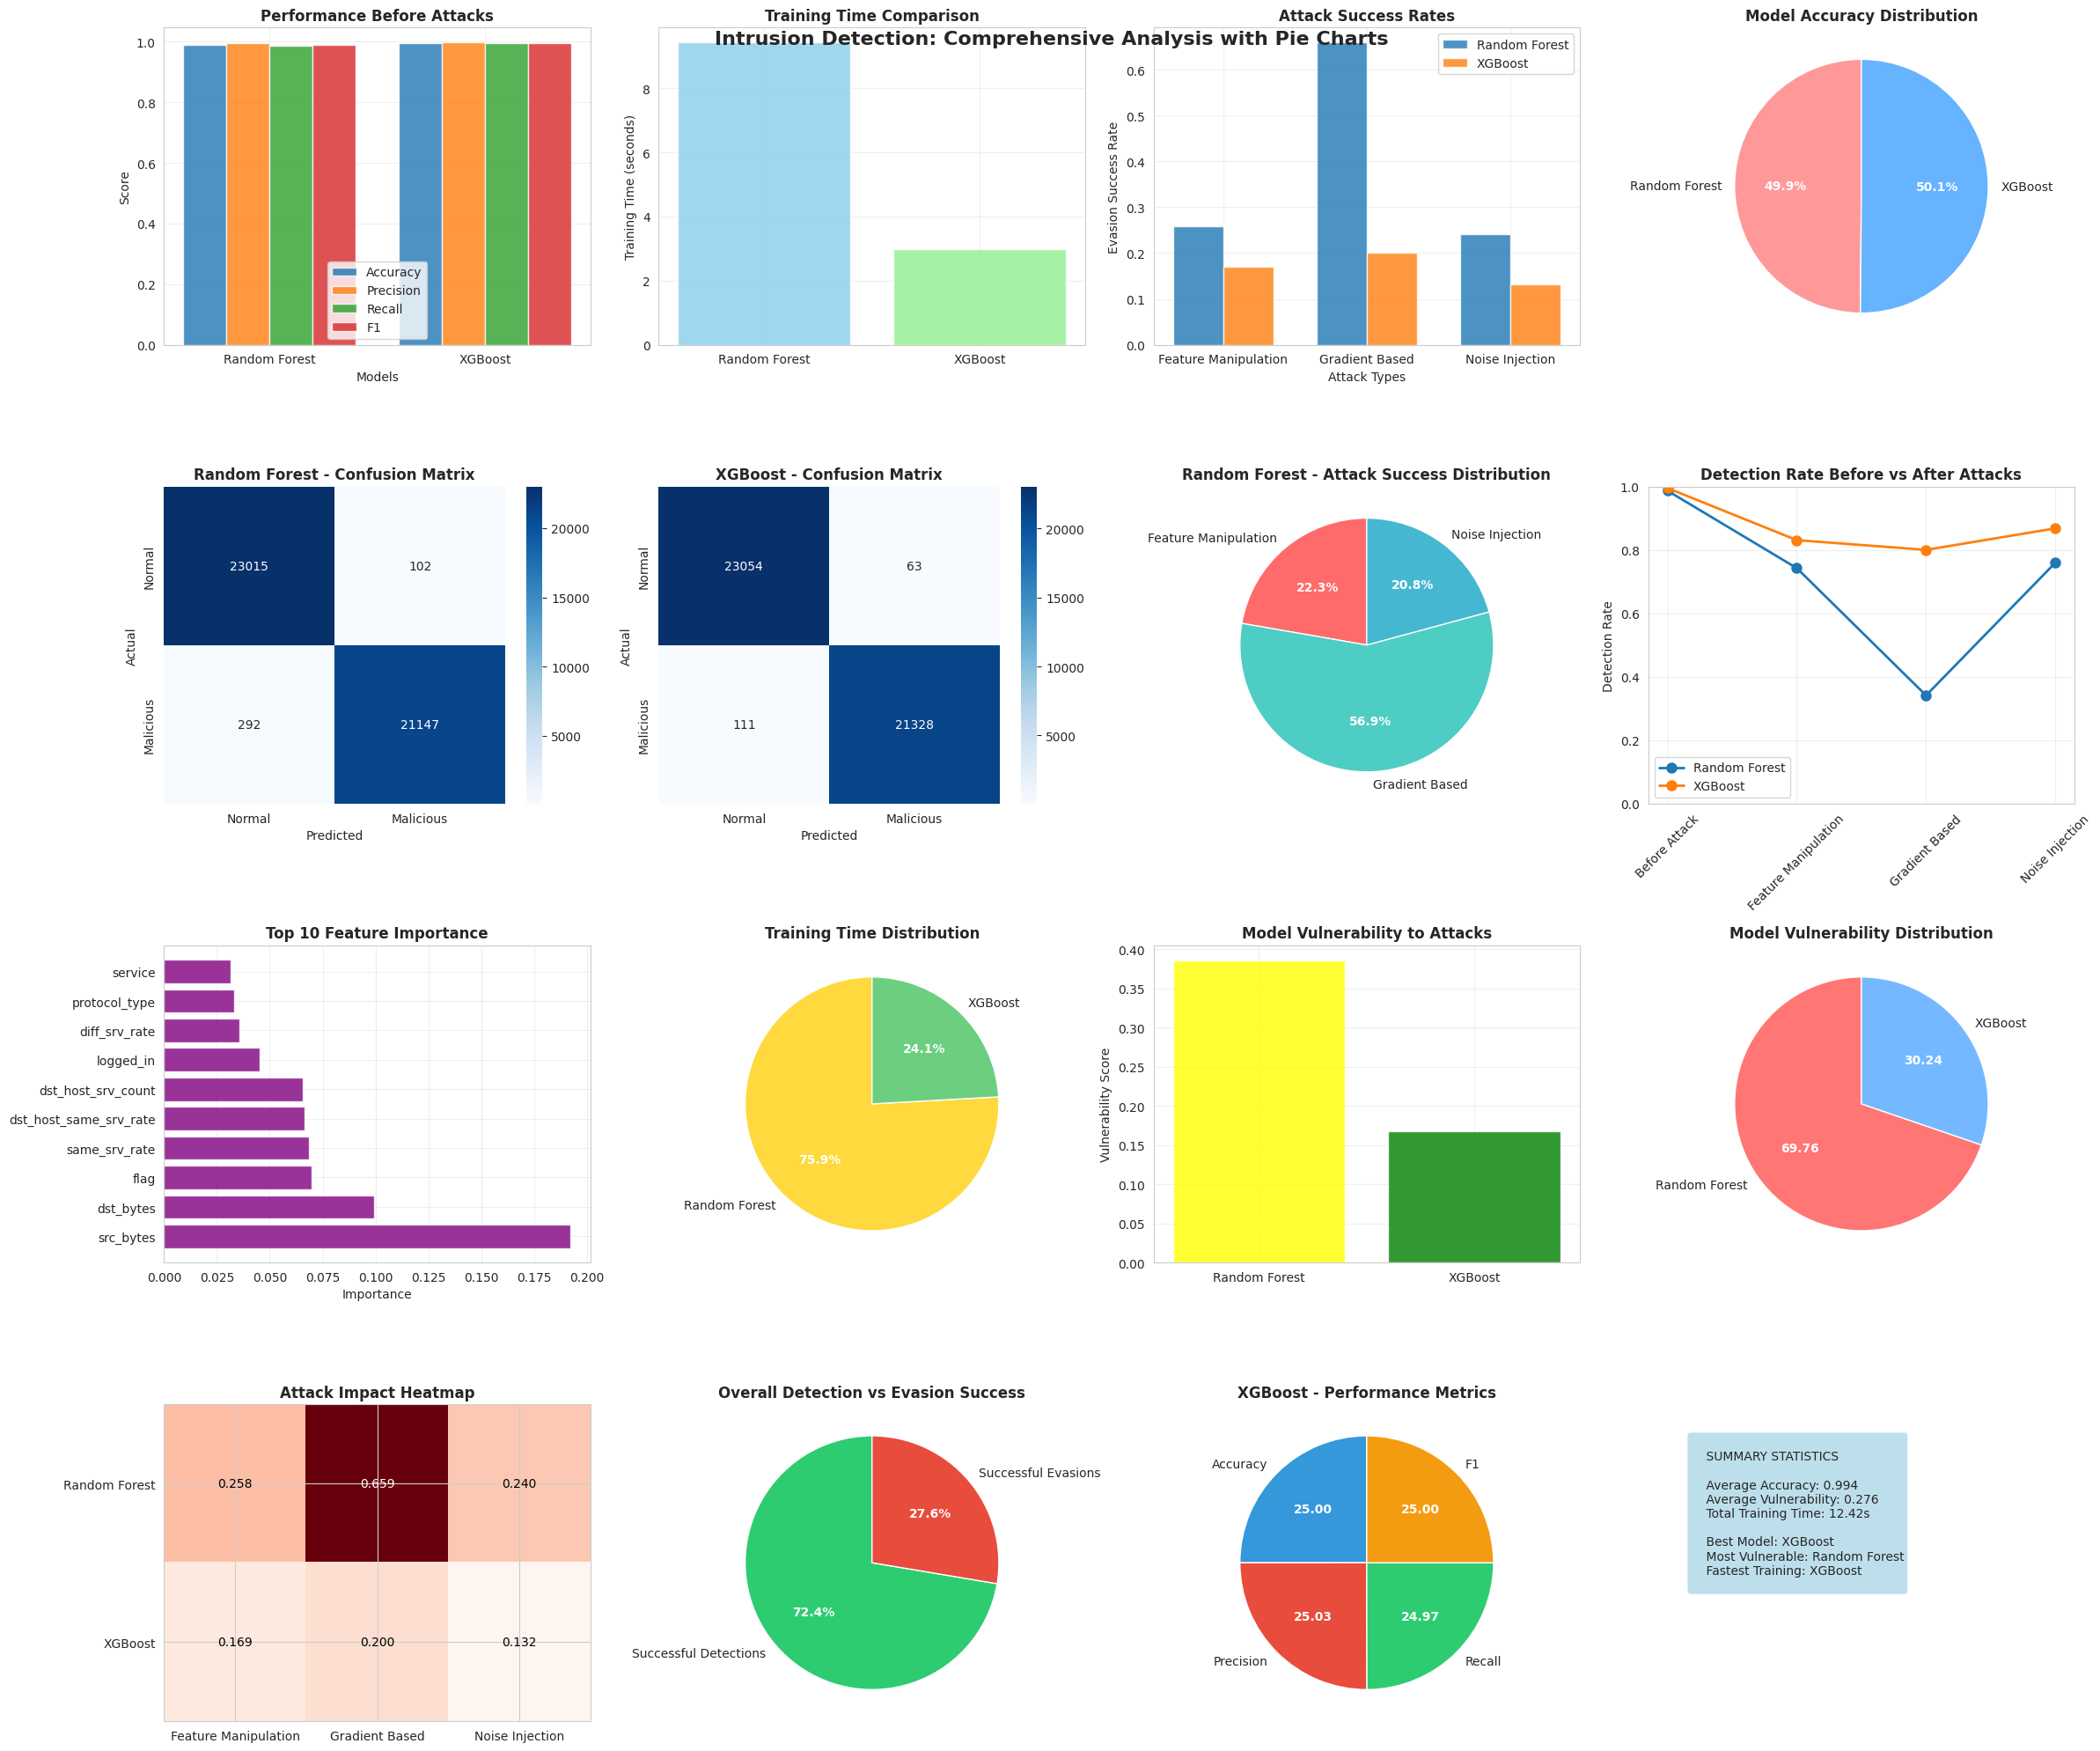

In [26]:
create_comprehensive_visualizations(intrusion_models, before_attack_results, after_attack_results, feature_names)  # Make charts
